# Zadanie 1: Klasteryzacja klientów

<div style="display: flex; justify-content: center;">
<img src=".//Images//bikes_market.png" alt="bikes_market" width="600" height="200" style="margin: 10px;"/>
</div>

**Segmentacja klientów na podstawie danych demograficznych i stylu życia**

**Opis zadania:**

Jako analityk danych pracujesz dla firmy zajmującej się sprzedażą rowerów. Twoim zadaniem jest przeprowadzenie analizy segmentacyjnej klientów na podstawie ich cech demograficznych i stylu życia.

Celem segmentacji jest:

* lepsze zrozumienie różnych typów klientów,
* dostosowanie oferty marketingowej do poszczególnych segmentów,
* wyodrębnienie grup z największym potencjałem zakupowym.

**Zakres pracy:**

1. **Przygotuj dane do analizy (`Dataset - Bikes.xlsx`):**

   * wybierz istotne zmienne do klasteryzacji (np. `Income`, `Age`, `Children`, `Cars`, `Commute Distance`, `Education`),
   * zakoduj zmienne kategoryczne (np. `Education`, `Commute Distance`) w postaci liczbowej,
   * przeskaluj dane.

2. **Wykonaj klasteryzację:**

   * **K-means (3 klastry)**,

3. **Wizualizuj wyniki:**

   * zastosuj wykres 2D (PCA) porównujący klastry.
  
3. **Zinterpretuj uzyskane klastry:**

   * opisz każdy segment: czym się charakteryzuje, co go odróżnia od innych,
   * sprawdź, czy w klastrach różni się częstość zakupu roweru (`Purchased Bike`).

---

In [1]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
%pip install -q matplotlib seaborn openpyxl mlxtend


Note: you may need to restart the kernel to use updated packages.


c:\Users\251190\Downloads\ML\.venv\Scripts\python.exe: No module named pip


<span style="color: red; font-weight: bold;">Wczytanie zbioru</span>

In [2]:
# dane z pliku Excel
file_path = "./data/Dataset - Bikes.xlsx"

# Wczytanie danych z arkusza
df_bikes = pd.read_excel(file_path)

# Podgląd danych
df_bikes.head()

,ID,Marital Status,Gender,Income,Children,Education,Occupation,Home Owner,Cars,Commute Distance,Region,Age,Purchased Bike
0,12496,Married,Female,40000,1,Bachelors,Skilled Manual,Yes,0,0-1 Miles,Europe,42,No
1,24107,Married,Male,30000,3,Partial College,Clerical,Yes,1,0-1 Miles,Europe,55,No
2,14177,Married,Male,80000,5,Partial College,Professional,No,2,2-5 Miles,Europe,60,No
3,24381,Single,Male,70000,0,Bachelors,Professional,Yes,1,5-10 Miles,Pacific,41,Yes
4,13507,Married,Female,10000,2,Partial College,Manual,Yes,0,1-2 Miles,Europe,50,No


<span style="color: red; font-weight: bold;">Wybór cech do analizy</span>

In [18]:

# Wybór cech do analizy
features = ['Income', 'Age', 'Children', 'Cars', 'Education', 'Commute Distance']
target = 'Purchased Bike'

df_model = df_bikes[features + [target]].dropna().copy()
df_model.head()


,Income,Age,Children,Cars,Education,Commute Distance,Purchased Bike
0,40000,42,1,0,Bachelors,0-1 Miles,No
1,30000,55,3,1,Partial College,0-1 Miles,No
2,80000,60,5,2,Partial College,2-5 Miles,No
3,70000,41,0,1,Bachelors,5-10 Miles,Yes
4,10000,50,2,0,Partial College,1-2 Miles,No


<span style="color: red; font-weight: bold;">Kodowanie zmiennych kategorycznych</span>

In [19]:

# Kodowanie zmiennych kategorycznych
le = LabelEncoder()
df_model['Education'] = le.fit_transform(df_model['Education'])
df_model['Commute Distance'] = le.fit_transform(df_model['Commute Distance'])
df_model.head()


,Income,Age,Children,Cars,Education,Commute Distance,Purchased Bike
0,40000,42,1,0,0,0,No
1,30000,55,3,1,3,0,No
2,80000,60,5,2,3,3,No
3,70000,41,0,1,0,4,Yes
4,10000,50,2,0,3,1,No


<span style="color: red; font-weight: bold;">Standaryzacja</span>

In [20]:

# Standaryzacja
X = df_model[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


<span style="color: red; font-weight: bold;">Klasteryzacja KMeans (3 klastry)</span>

In [21]:

# Klasteryzacja KMeans (3 klastry)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['cluster'] = kmeans.fit_predict(X_scaled)
df_model['cluster'].value_counts()


cluster
2    379
0    313
1    306
Name: count, dtype: int64

<span style="color: red; font-weight: bold;">Redukcja wymiarowości do 2D (PCA, n_components=2) i wizualizacja</span>

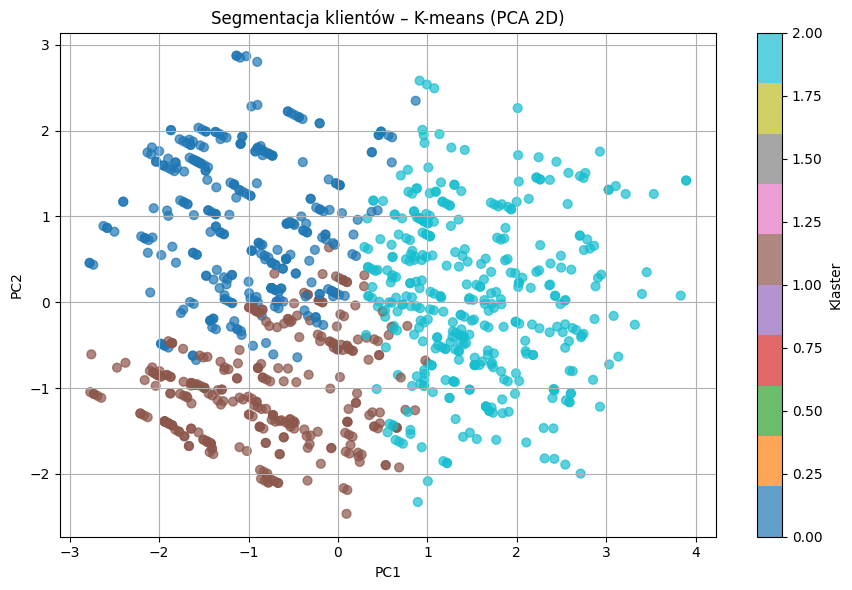

In [7]:

# Redukcja wymiarowości do 2D (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Wizualizacja
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df_model['cluster'], cmap='tab10', s=40, alpha=0.7)
plt.colorbar(scatter, label='Klaster')
plt.title('Segmentacja klientów – K-means (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


Powyższy wykres przedstawia wynik segmentacji klientów metodą K-means na podstawie danych demograficznych, zredukowanych do dwóch głównych składowych (PCA). Każdy punkt to klient, a kolory odpowiadają 3 wyodrębnionym klastrom.

<span style="color: red; font-weight: bold;">Zinterpretuj uzyskane klastry</span>


**Interpretacja klastrów:**

Poniżej zestawienie średnich cech dla każdego klastra:


In [8]:

# Średnie cechy w każdym klastrze
print(df_model.groupby('cluster')[features].mean().round(2))
print()
# Udział zakupów roweru w każdym klastrze
print("Zakup roweru wg klastra:")
print(df_model.groupby('cluster')['Purchased Bike'].value_counts(normalize=True).unstack().round(2))


           Income    Age  Children  Cars  Education  Commute Distance
cluster                                                              
0        32428.12  37.43      1.04  1.33       2.89              1.56
1        55947.71  40.62      1.28  0.46       0.41              0.98
2        76068.60  52.71      3.14  2.36       1.58              2.26

Zakup roweru wg klastra:
Purchased Bike    No   Yes
cluster                   
0               0.59  0.41
1               0.35  0.65
2               0.60  0.40


---

# Zadanie 2: Analiza koszykowa – reguły asocjacyjne

<div style="display: flex; justify-content: center;">
<img src=".//Images//bikes.png" alt="bikes" width="600" height="200" style="margin: 10px;"/>
</div>

**Odkrywanie powiązań zakupowych pomiędzy produktami w danych sprzedażowych**

---

**Opis zadania:**

Twoim zadaniem jest przeprowadzenie analizy koszykowej (market basket analysis) na danych z zamówień klientów. Celem jest identyfikacja produktów, które są często kupowane razem, w celu:

* lepszego zrozumienia zachowań zakupowych klientów,
* tworzenia promocji wiązanych („kup X, a otrzymasz zniżkę na Y”),
* optymalizacji układu produktów w sklepie.

---

**Zakres pracy:**

1. **Przygotuj dane (`Dataset - Associate`):**

   * potraktuj każde `Order Number` jako osobną transakcję (koszyk),
   * każda transakcja powinna zawierać listę nazw produktów.

2. **Przeprowadź kodowanie danych:**

   * zastosuj `TransactionEncoder` z `mlxtend.preprocessing`,
   * uzyskaj macierz binarną: wiersze = transakcje, kolumny = produkty.

3. **Zidentyfikuj częste zestawy produktów:**

   * użyj funkcji `apriori()` z `mlxtend.frequent_patterns`,
   * ustal minimalne wsparcie (support), np. 1–2%.

4. **Wygeneruj reguły asocjacyjne:**

   * zastosuj `association_rules()` z odpowiednimi progami `confidence` i `lift`,
   * posortuj i zaprezentuj najciekawsze reguły.

5. **Zinterpretuj wyniki:**

   * opisz, które produkty są najczęściej kupowane razem,

---

**Dodatkowo (opcjonalnie):**

* Stwórz wykres `support vs confidence` (kolor = lift),
* Przeanalizuj wpływ ustawienia różnych progów `support` i `confidence`.

---

In [9]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [10]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

<span style="color: red; font-weight: bold;">Wczytanie zbioru</span>

In [11]:
# Ścieżka do pliku
file_path = "./data/Dataset - Associate.xlsx"

# Wczytanie danych z arkusza "Associate"
df_associate = pd.read_excel(file_path)

# Podgląd danych
df_associate.head()

,Order Number,Category,Product,Product Price
0,SO61269,Helmets,Sport-100,53.99
1,SO61269,Jerseys,Long-Sleeve Logo Jersey,49.99
2,SO61270,Fenders,Fender Set - Mountain,21.98
3,SO61271,Tires and Tubes,LL Road Tire,21.49
4,SO61271,Tires and Tubes,Patch kit,564.99


In [12]:
# Połączenie 'Product' i 'Category' w jedną kolumnę, np. 'Product (Category)'
df_associate['Product_Full'] = df_associate['Product'] + ' (' + df_associate['Category'] + ')'

# Usunięcie oryginalnych kolumn 'Product' i 'Category', zostawiając tylko 'Product_Full'
df_associate = df_associate.drop(columns=['Product', 'Category', 'Product Price'])

In [15]:
df_associate.shape

(32265, 2)

In [16]:
df_associate.head()

,Order Number,Product_Full
0,SO61269,Sport-100 (Helmets)
1,SO61269,Long-Sleeve Logo Jersey (Jerseys)
2,SO61270,Fender Set - Mountain (Fenders)
3,SO61271,LL Road Tire (Tires and Tubes)
4,SO61271,Patch kit (Tires and Tubes)


<span style="color: red; font-weight: bold;">Grupowanie produktów według numeru zamówienia</span>

In [13]:

# Grupowanie produktów według numeru zamówienia
basket = df_associate.groupby('Order Number')['Product_Full'].apply(list)
transactions = basket.tolist()
print(f"Liczba transakcji: {len(transactions)}")
print("Przykład transakcji:", transactions[0])


Liczba transakcji: 13050
Przykład transakcji: ['Sport-100 (Helmets)', 'Long-Sleeve Logo Jersey (Jerseys)']


<span style="color: red; font-weight: bold;">Kodowanie transakcji</span>

In [14]:

# Kodowanie transakcji
te = TransactionEncoder()
df_encoded = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)
df_encoded.shape


(13050, 37)

<span style="color: red; font-weight: bold;">Zidentyfikuj częste zestawy produktów</span>

In [15]:

# Apriori – zestawy częste (min_support=0.01)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
print(f"Liczba częstych zestawów: {len(frequent_itemsets)}")
frequent_itemsets.sort_values('support', ascending=False).head(10)


Liczba częstych zestawów: 113


,support,itemsets
28,0.290728,frozenset({Sport-100 (Helmets)})
34,0.191724,frozenset({Water Bottle (Bottles and Cages)})
19,0.140613,frozenset({Patch kit (Tires and Tubes)})
15,0.136552,frozenset({Mountain Tire Tube (Tires and Tubes)})
16,0.112874,frozenset({Mountain-200 (Mountain Bikes)})
22,0.105517,frozenset({Road Tire Tube (Tires and Tubes)})
2,0.100000,frozenset({Cycling Cap (Caps)})
3,0.094866,frozenset({Fender Set - Mountain (Fenders)})
14,0.092031,frozenset({Mountain Bottle Cage (Bottles and C...
11,0.080690,frozenset({Long-Sleeve Logo Jersey (Jerseys)})


<span style="color: red; font-weight: bold;">Wygeneruj reguły asocjacyjne, zaprezentuj najciekawsze reguły</span>

In [16]:

# Reguły asocjacyjne
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Dodaj czytelne etykiety
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

# 10 najlepszych reguł wg lift
top_rules = rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']] \
    .sort_values('lift', ascending=False).head(10)
print(top_rules.to_string(index=False))


                                                    antecedents_str                          consequents_str  support  confidence      lift
Mountain Tire Tube (Tires and Tubes), Mountain-200 (Mountain Bikes)       HL Mountain Tire (Tires and Tubes) 0.015632    1.000000 15.992647
                Sport-100 (Helmets), Touring Tire (Tires and Tubes)      Touring Tire Tube (Tires and Tubes) 0.012644    1.000000 14.548495
        Patch kit (Tires and Tubes), Touring Tire (Tires and Tubes)      Touring Tire Tube (Tires and Tubes) 0.010115    0.949640 13.815837
     Touring-1000 (Touring Bikes), Water Bottle (Bottles and Cages)     Road Bottle Cage (Bottles and Cages) 0.014943    1.000000 12.985075
            Road-750 (Road Bikes), Water Bottle (Bottles and Cages)     Road Bottle Cage (Bottles and Cages) 0.021303    1.000000 12.985075
   Patch kit (Tires and Tubes), Touring Tire Tube (Tires and Tubes)           Touring Tire (Tires and Tubes) 0.010115    0.568966 12.757732
                    

<span style="color: red; font-weight: bold;">Zinterpretuj wyniki</span>

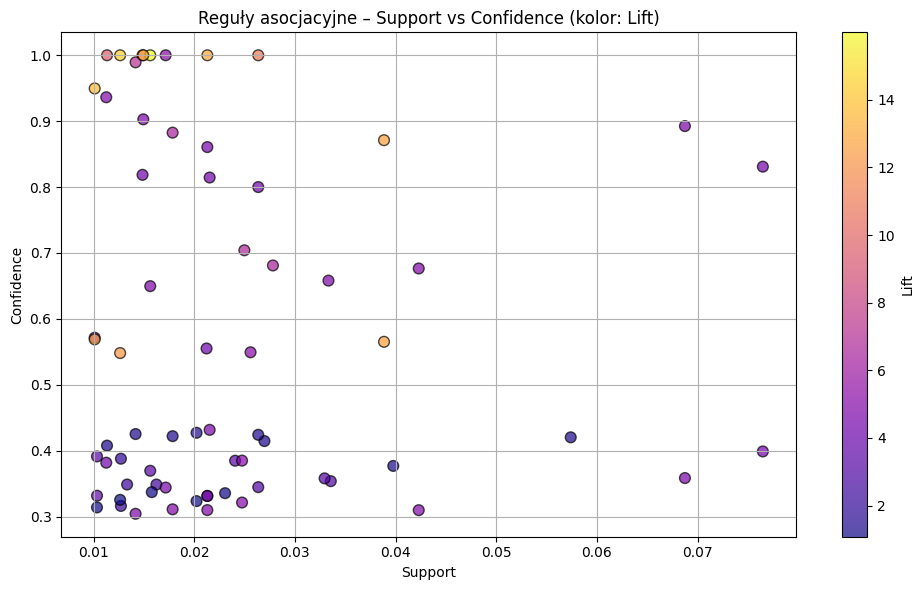

In [17]:

import matplotlib.pyplot as plt

# Wykres support vs confidence, kolor = lift
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='plasma',
    s=60,
    alpha=0.7,
    edgecolors='k'
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Reguły asocjacyjne – Support vs Confidence (kolor: Lift)')
plt.grid(True)
plt.tight_layout()
plt.show()
